In [1]:
# ======================================================
# Bagged Trees on Fruit Disease Dataset
# ======================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from tqdm import tqdm


In [3]:
# ======================================================
# Paths
# ======================================================
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"
IMAGE_SIZE = (128, 128)


In [4]:

# ======================================================
# Load Training Dataset
# ======================================================
X, y = [], []
print("📦 Loading training dataset...")
for label in tqdm(os.listdir(TRAIN_DIR)):
    label_path = os.path.join(TRAIN_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X.append(img_array)
            y.append(label)
        except:
            pass

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
print(f"✅ Loaded {len(X)} images from {len(np.unique(y))} classes.")

📦 Loading training dataset...


100%|██████████| 21/21 [08:50<00:00, 25.24s/it]


✅ Loaded 6399 images from 21 classes.


In [5]:
# ======================================================
# Train-Validation Split
# ======================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# ======================================================
# Flatten for tree input
# ======================================================
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

# Standardize features
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_val_flat = scaler.transform(X_val_flat)

In [7]:

# ======================================================
# Train Bagged Tree Classifier
# ======================================================
print("\n🚀 Training Bagged Trees...")
bagged_tree = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,      # number of trees
    max_samples=0.8,      # fraction of samples per tree
    max_features=1.0,     # fraction of features per tree
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagged_tree.fit(X_train_flat, y_train_enc)



🚀 Training Bagged Trees...


BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.8,
                  n_estimators=50, n_jobs=-1, random_state=42)

In [8]:
# ======================================================
# Evaluate on Validation
# ======================================================
y_pred_val = bagged_tree.predict(X_val_flat)
print("\n✅ Validation Results:")
print("Accuracy:", accuracy_score(y_val_enc, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_val_enc, y_pred_val, target_names=label_encoder.classes_))

# ======================================================
# Load Test Dataset
# ======================================================
X_test, y_test = [], []
print("\n📦 Loading test dataset...")
for label in tqdm(os.listdir(TEST_DIR)):
    label_path = os.path.join(TEST_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X_test.append(img_array)
            y_test.append(label)
        except:
            pass

X_test = np.array(X_test, dtype="float32") / 255.0
y_test = np.array(y_test)

X_test_flat = X_test.reshape(len(X_test), -1)
X_test_flat = scaler.transform(X_test_flat)
y_test_enc = label_encoder.transform(y_test)



✅ Validation Results:
Accuracy: 0.83125

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.81      0.96      0.88       198
                         Grape__black_rot       0.76      0.75      0.75       142
                           Grape__healthy       0.91      0.60      0.73        68
Grape__leaf_blight_(isariopsis_leaf_spot)       0.83      0.88      0.86       128
                          Lemon__diseased       0.50      0.70      0.58        10
                           Lemon__healthy       0.80      0.91      0.85        22
                    Pomegranate__diseased       0.94      0.89      0.92        38
                     Pomegranate__healthy       0.88      0.93      0.90        40
                       guava_Disease Free       0.60      0.50      0.55        18
                        guava_Phytopthora       0.40      0.12      0.19        16
                     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 21/21 [03:20<00:00,  9.53s/it]


In [9]:
# ======================================================
# Predict on Test Data
# ======================================================
y_pred_test = bagged_tree.predict(X_test_flat)


In [10]:

# ======================================================
# Evaluation Metrics
# ======================================================
acc = accuracy_score(y_test_enc, y_pred_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred_test, average='weighted')

print("\n🎯 Test Results (Bagged Trees):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_test, target_names=label_encoder.classes_))


🎯 Test Results (Bagged Trees):
Accuracy: 0.7992
Precision: 0.7921
Recall: 0.7992
F1 Score: 0.7882

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.77      0.95      0.85       277
                         Grape__black_rot       0.71      0.70      0.71       200
                           Grape__healthy       0.81      0.61      0.70        94
Grape__leaf_blight_(isariopsis_leaf_spot)       0.81      0.86      0.84       178
                          Lemon__diseased       0.59      0.62      0.61        16
                           Lemon__healthy       0.77      0.75      0.76        32
                    Pomegranate__diseased       0.93      0.93      0.93        55
                     Pomegranate__healthy       0.83      0.95      0.89        58
                       guava_Disease Free       0.69      0.69      0.69        26
                        guava_Phytopthora     

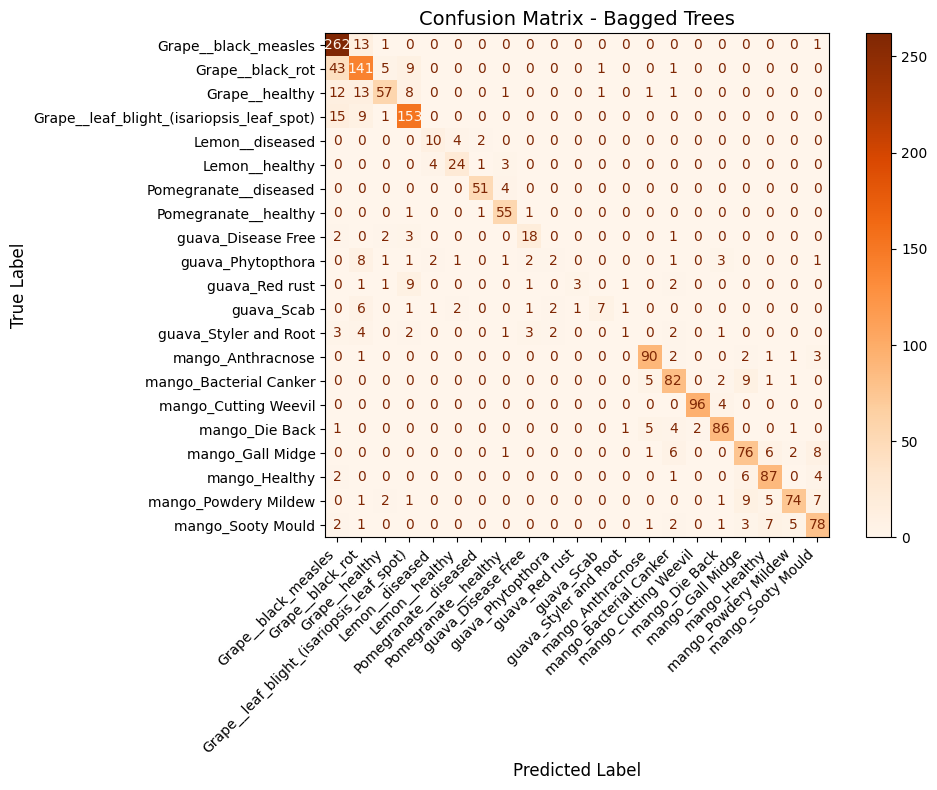

In [11]:
cm = confusion_matrix(y_test_enc, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(max(8, len(label_encoder.classes_) * 0.5), 8))
disp.plot(cmap="Oranges", ax=ax, colorbar=True)

plt.title("Confusion Matrix - Bagged Trees", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


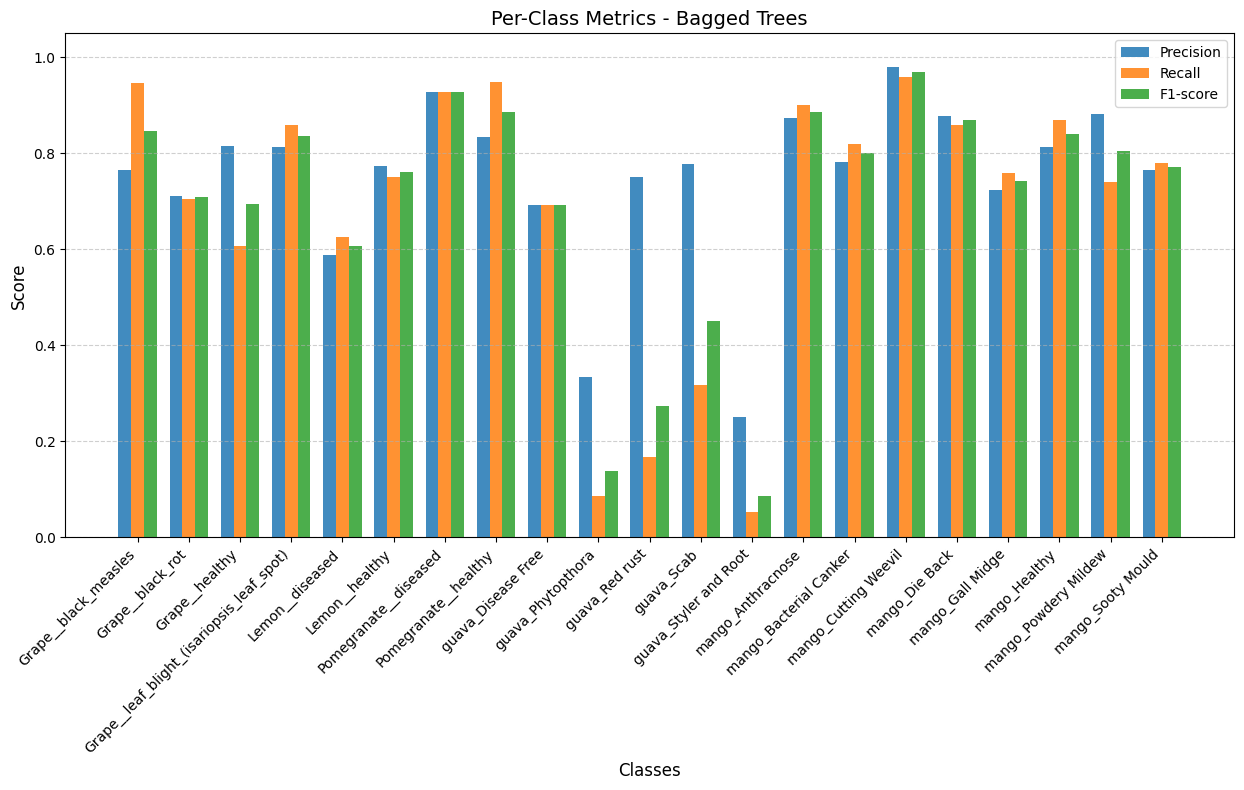

In [12]:

precisions, recalls, f1s, _ = precision_recall_fscore_support(y_test_enc, y_pred_test, zero_division=0)

# X-axis positions
x = np.arange(len(label_encoder.classes_))
bar_width = 0.25

plt.figure(figsize=(max(10, len(label_encoder.classes_) * 0.6), 8))

plt.bar(x - bar_width, precisions, width=bar_width, label='Precision', alpha=0.85)
plt.bar(x, recalls, width=bar_width, label='Recall', alpha=0.85)
plt.bar(x + bar_width, f1s, width=bar_width, label='F1-score', alpha=0.85)

plt.xticks(x, label_encoder.classes_, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)
plt.title("Per-Class Metrics - Bagged Trees", fontsize=14)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
